# Exercise 06: Distributed Computing for LLM Training

In this notebook, we extend the EX04 single-GPU training loop to multi-GPU training with:
- **Distributed Data Parallel (DDP)** = parallelism across GPUs
- **gradient accumulation (GA)** = accumulation over steps / time
- **DGX execution with `torchrun`** (PyTorch's distributed launcher: run from terminal using a training script)

Example launch command:
```bash
CUDA_VISIBLE_DEVICES=0,1 uv run torchrun --standalone --nnodes=1 --nproc_per_node=2 train_ddp.py
```

In EX04, the essential pattern was:
- we cannot fit whole dataset in memory -> process in baches:  Each batch corresponds to one training step / one optimizer update
```python
for batch in loader:
    optimizer.zero_grad(set_to_none=True)
    logits = model(input_ids, padding_mask=padding_mask)
    loss = cross_entropy(...)
    loss.backward()
    optimizer.step()
    scheduler.step()
```

<img src="images/Global_vs_minibatch.jpg" width="1000">
Source: https://kaitchup.substack.com/p/the-faulty-gradient-accumulation

## Gradient accumulation
Left: GA for 1 GPU

- Gradient Accumulation is NOT a parallelization technique and does NOT require multiple GPUs. Useful when the full batch does not fit into GPU memory
- achieve same batch size but never load the whole batch at once, instead of one large batch at once, processes sequential mini-batches
-  **Gradient accumulation delays optimizer update**: keep the EX04 training logic, but call `optimizer.step()` only every `grad_accum_steps` / k / mini-batches.

## DDP
- a full copy of the model, process different data in parallel
- computes forward and backward independently, different gradients per GPU
- synchronizes gradients across GPUs (all reduce): sum all gradients, computing the average, and communicating the average back to all other GPUs
- applies the same weight update on every GPU.
- Without accumulation, gradients are synchronized every step.

| Technique | Parallel across GPUs? | Accumulates over time? | When do gradients sync across GPUs?       | Optimizer step        | Effective batch |
|---|---|---|-------------------------------------------|-----------------------|---|
| Single GPU (no GA) | No | No | -                                         | Every batch           | `B` |
| Gradient Accumulation (1 GPU) | No | Yes | -                                         | Every `K` steps       | `B * K` |
| DDP (no GA) | Yes | No | Every step (during backward) (all-reduce) | Every step | `B * N` |
| DDP + GA | Yes | Yes | Every `K` steps (all reduce)              | Every `K` steps       | `B * N * K` |


## DDP + GA
1. Each GPU processes one local micro-batch.
2. This happens in parallel on all GPUs.
3. Each GPU accumulates gradients locally for `k = grad_accum_steps` micro-steps (no reset)
4. Gradients are synchronized across GPUs using all-reduce, typically during each backward pass (for no_sny variant only at final step), and after K accumulation steps all GPUs apply the same optimizer update.

<img src="images/grad_acc_dat_par.png" width="1000">
Source: https://towardsdatascience.com/ai-in-multiple-gpus-grad-accum-data-parallelism

In [14]:
import os
import time
import math
import torch
import torch.nn.functional as F
import torch.distributed as dist

from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader, Dataset
from torch.utils.data.distributed import DistributedSampler

In [15]:
# Same toy setup style as EX04, so only the training orchestration changes.
class ToyNextTokenDataset(Dataset):
    def __init__(self, num_samples=256, seq_len=64, vocab_size=100, pad_token_id=0):
        self.num_samples = num_samples
        self.seq_len = seq_len
        self.vocab_size = vocab_size
        self.pad_token_id = pad_token_id

    def __len__(self):
        # Number of training examples in this dataset.
        return self.num_samples

    def __getitem__(self, idx):
        # Random token IDs in [1, vocab_size-1]. Token 0 is reserved for padding.
        input_ids = torch.randint(1, self.vocab_size, (self.seq_len,), dtype=torch.long)

        # Simulate variable-length sequences to demonstrate padding effects.
        effective_len = torch.randint(low=self.seq_len // 2, high=self.seq_len + 1, size=(1,)).item()
        padding_mask = torch.zeros(self.seq_len, dtype=torch.bool)
        padding_mask[:effective_len] = True  # True = real token, False = padding
        input_ids[~padding_mask] = self.pad_token_id

        # Labels are next-token targets; padded positions are ignored with -100.
        labels = input_ids.clone()
        labels[~padding_mask] = -100
        return {"input_ids": input_ids, "labels": labels, "padding_mask": padding_mask}


class TinyLanguageModel(nn.Module):
    def __init__(self, vocab_size=100, hidden_dim=128):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, hidden_dim)  # [B,S] -> [B,S,H]
        self.ff = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, vocab_size),  # [B,S,H] -> [B,S,V]
        )

    def forward(self, input_ids, padding_mask=None):
        # padding_mask is passed to mirror a real LM API.
        x = self.embed(input_ids)
        return self.ff(x)

In [ ]:
def setup_distributed():
    """Initialize process group and return rank info + device (CPU or GPU)."""
    local_rank = int(os.environ.get("LOCAL_RANK", 0))  # Provided by torchrun.
    use_cuda = torch.cuda.is_available()
    backend = "nccl" if use_cuda else "gloo"  # NCCL for NVIDIA GPUs, Gloo for CPU fallback.
    dist.init_process_group(backend=backend)

    rank = dist.get_rank()  # Global process id (0 ... world_size-1).
    world_size = dist.get_world_size()  # Total number of processes.

    if use_cuda:
        device = torch.device(f"cuda:{local_rank}")
        torch.cuda.set_device(local_rank)  # Ensure this process only uses its assigned GPU.
    else:
        device = torch.device("cpu")

    print(
        f"[rank {rank}/{world_size}] local_rank={local_rank} device={device}",
        flush=True,
    )
    return rank, world_size, local_rank, device


def cleanup_distributed():
    # Clean shutdown so repeated runs do not leave hanging process groups.
    if dist.is_initialized():
        dist.destroy_process_group()


## Faulty Gradient Accumulation: What to Avoid

If micro-batches have different numbers of valid (non-pad) tokens, then this is biased:

loss = cross_entropy(..., reduction="mean")
loss = loss / grad_accum_steps
loss.backward()

Why: each micro-batch contributes equally, even when the number of valid tokens differs.

Correct approach:
1. use reduction="sum" so each micro-batch contributes its total token loss,
2. accumulate gradients across the whole accumulation window,
3. normalize once by the total number of valid tokens in that window
   (and across all GPUs in DDP).

This gives gradients corresponding to the average loss per valid token,
not the average of per-micro-batch means.

In [16]:

# runs once per GPU process.
def train_one_epoch_ddp(
    model,
    loader,
    optimizer,
    scheduler,
    device,
    grad_accum_steps=4,
    log_every=20,
):
    model.train()
    running_loss = 0.0
    epoch_tokens_local = 0
    optimizer_updates = 0
    optimizer.zero_grad(set_to_none=True)  # Start with empty gradient buffers.
    token_count_window = 0  # Number of valid tokens since last optimizer step.
    world_size = dist.get_world_size()

    for step, batch in enumerate(loader, start=1): # For each micro-step:
        # Move this micro-batch to the local GPU.
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)
        padding_mask = batch["padding_mask"].to(device, non_blocking=True).bool()

        # Forward pass on local GPU.
        logits = model(input_ids, padding_mask=padding_mask)

        # Shift for next-token prediction: predict token t+1 from positions <= t.
        logits_shift = logits[:, :-1, :].contiguous()
        labels_shift = labels[:, 1:].contiguous()

        vocab_size = logits_shift.size(-1)
        # IMPORTANT: sum (not mean) so token weighting is handled globally, not per micro-batch mean.
        loss = F.cross_entropy(
            logits_shift.view(-1, vocab_size),
            labels_shift.view(-1),
            ignore_index=-100,
            reduction="sum",
        )

        # Count valid targets (non-padding) for this micro-batch.
        valid_tokens = (labels_shift != -100).sum().item()
        epoch_tokens_local += valid_tokens
        token_count_window += valid_tokens

        # if false: no_sync() -> accumulate local gradients, no cross GPU communication
        # if true: DDP all-reduces gradients across GPUs.
        should_sync = (step % grad_accum_steps == 0) or (step == len(loader))
        if should_sync:
            # On sync step, DDP performs all-reduce during backward.
            loss.backward()
        else:
            # On non-sync steps, accumulate local grads only (faster, less communication).
            with model.no_sync():
                loss.backward()

        # on sny step
        if should_sync:
            local_tokens_window = token_count_window

            # Count valid targets across all ranks for this accumulation window.
            token_tensor = torch.tensor(token_count_window, device=device, dtype=torch.float32)
            dist.all_reduce(token_tensor, op=dist.ReduceOp.SUM)
            total_tokens_global = token_tensor.item()

            # Scaling for correct token normalization
            # - Loss uses reduction="sum" (token-summed loss).
            # - DDP averages gradients across ranks (GPUs) after sync.
            # We want gradient per valid token globally.
            # So: cancel DDP averaging (* world_size), then normalize by total valid tokens.
            grad_scale = world_size / max(total_tokens_global, 1.0)
            # = make each parameter’s gradient the average gradient per valid token for that update


            for p in model.parameters():
                if p.grad is not None:
                    p.grad.mul_(grad_scale) # every gradient is rescaled before optimizer step

            optimizer.step()  # Apply one update for the full accumulation window.
            scheduler.step()  # Keep LR schedule aligned with optimizer steps.
            optimizer_updates += 1
            update_step = (step + grad_accum_steps - 1) // grad_accum_steps
            if dist.get_rank() == 0:
                lr = optimizer.param_groups[0]["lr"]
                print(
                    "[sync] "
                    f"micro_step={step:04d} update_step={update_step:04d} "
                    f"local_tokens_window={local_tokens_window} "
                    f"global_tokens_window={int(total_tokens_global)} "
                    f"grad_scale={grad_scale:.6e} lr={lr:.2e}",
                    flush=True,
                )
            optimizer.zero_grad(set_to_none=True)  # Reset buffers for next window.
            token_count_window = 0

        # Logging metric only: average token loss for this micro-batch.
        running_loss += loss.item() / max(valid_tokens, 1)

        if step % log_every == 0 and dist.get_rank() == 0:
            lr = optimizer.param_groups[0]["lr"]
            print(f"step={step:04d} avg_micro_loss={running_loss/step:.4f} lr={lr:.2e}")

    epoch_tokens_tensor = torch.tensor(epoch_tokens_local, device=device, dtype=torch.float64)
    dist.all_reduce(epoch_tokens_tensor, op=dist.ReduceOp.SUM)
    epoch_tokens_global = int(epoch_tokens_tensor.item())
    return {
        "train_loss_epoch": running_loss / len(loader),
        "epoch_tokens_global": epoch_tokens_global,
        "optimizer_updates": optimizer_updates,
    }

In [17]:
def main_ddp():
    # torchrun --nproc_per_node=2 -> Every process / GPU runs this main function once: initialize distributed mode, build model, different data shard via DistributedSampler, training, Synchronizes gradients with other process(es) on sync steps, applies the same optimizer update, so model weights stay identical across GPUs.”
    rank, world_size, local_rank, device = setup_distributed()
    torch.manual_seed(7 + rank)  # Different seed per rank avoids identical random batches.

    try:
        dataset = ToyNextTokenDataset(num_samples=1024, seq_len=64, vocab_size=100)
        # DistributedSampler splits dataset indices across ranks (no overlap within epoch)
        # Each process gets different mini-batches via `DistributedSampler`.
        sampler = DistributedSampler(dataset, num_replicas=world_size, rank=rank, shuffle=True)
        loader = DataLoader(
            dataset,
            batch_size=8,  # Per-GPU batch size (micro-batch size).
            sampler=sampler,
            num_workers=2,
            pin_memory=True,
            drop_last=True,  # Keeps micro-batch shapes consistent.
        )

        model = TinyLanguageModel(vocab_size=100, hidden_dim=128).to(device)
        # Wrap model so gradient synchronization happens automatically on backward sync steps.
        if device.type == "cuda":
            model = DDP(model, device_ids=[local_rank], output_device=local_rank)
        else:
            model = DDP(model)

        epochs = 2
        grad_accum_steps = int(os.environ.get("GRAD_ACCUM_STEPS", "4"))
        updates_per_epoch = math.ceil(len(loader) / grad_accum_steps)
        total_steps = updates_per_epoch * epochs  # Scheduler should track optimizer updates, not micro-steps.
        optimizer = AdamW(model.parameters(), lr=2e-4, weight_decay=0.01)
        scheduler = LambdaLR(optimizer, lr_lambda=lambda s: 1.0 - 0.8 * (s / max(total_steps, 1)))

        per_gpu_batch = 8
        if rank == 0:
            eff_batch = per_gpu_batch * world_size * grad_accum_steps
            print(
                f"[config] world_size={world_size} per_gpu_batch={per_gpu_batch} "
                f"grad_accum_steps={grad_accum_steps} effective_batch={eff_batch} "
                "(override with GRAD_ACCUM_STEPS=<int>)",
                flush=True,
            )
        for epoch in range(epochs):
            # Needed when shuffle=True so each epoch gets a fresh (but rank-consistent) shuffle.
            sampler.set_epoch(epoch)
            epoch_start = time.perf_counter()
            metrics = train_one_epoch_ddp(
                model=model,
                loader=loader,
                optimizer=optimizer,
                scheduler=scheduler,
                device=device,
                grad_accum_steps=grad_accum_steps,
                log_every=20,
            )
            epoch_time_s = time.perf_counter() - epoch_start
            if rank == 0:
                # Effective batch seen by one optimizer step across all GPUs.
                eff_batch = per_gpu_batch * world_size * grad_accum_steps
                tok_per_s = metrics["epoch_tokens_global"] / max(epoch_time_s, 1e-9)
                print(
                    f"[perf] epoch={epoch} epoch_time_s={epoch_time_s:.2f} "
                    f"tokens_per_s={tok_per_s:.1f} optimizer_updates={metrics['optimizer_updates']}",
                    flush=True,
                )
                print(f"epoch={epoch} metrics={metrics} effective_batch={eff_batch}")
    finally:
        cleanup_distributed()


# Important:
# Run with torchrun from terminal
# torchrun --standalone --nnodes=1 --nproc_per_node=4 train_ddp.py


<img src="images/nvidia-smi.png" width="1000">


These notebook code cells were consolidated into train_ddp.py so the training can be launched as a script on DGX with torchrun.


# Results
### 2 GPU Run (DDP)

**Command**
```bash
GRAD_ACCUM_STEPS=2 CUDA_VISIBLE_DEVICES=0,1 uv run torchrun --standalone --nnodes=1 --nproc_per_node=2 train_ddp.py
```

**Formula**
`effective_batch = per_gpu_batch * world_size * grad_accum_steps`

**Values in this run**
- `world_size = 2` (two DDP processes, one per GPU)
- `per_gpu_batch = 8` (each micro-batch size on each GPU)
- `grad_accum_steps = 2` (accumulate 2 micro-steps before each optimizer update)

**Effective batch**
- `effective_batch = 8 * 2 * 2 = 32`

**Interpretation (per epoch)**
- `optimizer_updates = 32`
- `micro_steps = 64` (because each update happens every 2 micro-steps)
- `global_tokens_window` is aggregated across both ranks before grad scaling.

<img src="images/2GPU_1.png" width="1000">
<img src="images/2GPU_2.png" width="1000">
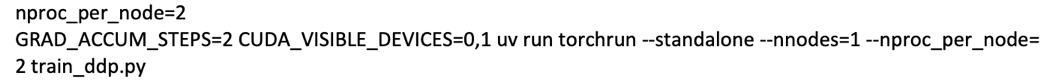


### 1 GPU Run (Reference)

**Command**
```bash
GRAD_ACCUM_STEPS=4 CUDA_VISIBLE_DEVICES=0 uv run torchrun --standalone --nnodes=1 --nproc_per_node=1 train_ddp.py
```

**Formula**
`effective_batch = per_gpu_batch * world_size * grad_accum_steps`

**Values in this run**
- `world_size = 1` (one DDP process on one GPU)
- `per_gpu_batch = 8` (each micro-batch size on that GPU)
- `grad_accum_steps = 4` (accumulate 4 micro-steps before each optimizer update)

**Effective batch**
- `effective_batch = 8 * 1 * 4 = 32`

**Interpretation (per epoch)**
- `optimizer_updates = 32`
- `micro_steps = 128` (because each update happens every 4 micro-steps)
- This setup matches the 2-GPU run at `effective_batch=32`, so the comparison is fair.

<img src="images/1GPU_1.png" width="1000">
<img src="images/1GPU_2.png" width="1000">


## Comparison

To compare fairly, keep `effective_batch` identical in both runs (`32` here).

| Metric | 1 GPU Run | 2 GPU Run | What it shows |
|---|---:|---:|---|
| `world_size` | 1 | 2 | number of DDP processes |
| `grad_accum_steps` | 4 | 2 | accumulation adjusted to match batch |
| `effective_batch` | 32 | 32 | fair apples-to-apples setup |
| `optimizer_updates` | 32 | 32 | same number of optimizer steps |
| `micro_steps` | 128 | 64 | fewer micro-steps needed with 2 GPUs |
| `tokens_per_s` (`[perf]`, epoch 0) | 76,287.7 | 94,392.6 | raw throughput at first epoch |
| `tokens_per_s` (`[perf]`, epoch 1) | 155,135.1 | 223,513.3 | throughput after warmup |
| `train_loss_epoch` (epoch 0) | 4.6310944 | 4.6319827 | similar training quality |
| `train_loss_epoch` (epoch 1) | 4.6251518 | 4.6269705 | similar training quality |

With the same effective batch and update count, the 2-GPU run improves throughput after warmup in this run, while keeping the loss trajectory similar.

Note: epoch-to-epoch timing can vary due to warmup/caching; compare multiple runs if you want stable speedup estimates.